# Exercise 17: Regularized regression

This homework assignment is designed to give you an intuition as an interesting property of regularization in the context of ultra-high dimensional statistical problems.

You won't need to load in any data for this homework.

---
## 1. Simulating & visualizing data (2 points)

We are going to be looking at what happens in the context where $p>n$. In order to have total control over our data, we will use simulations for this homework. First, we will need to load the `glmnet`, `tidyverse`, and `ggplot2` libraries for this assignment.


In [3]:
install.packages('glmnet')

lib <- c('glmnet', 'tidyverse', 'ggplot2')
lapply(lib, library, character.only = T)


The downloaded binary packages are in
	/var/folders/5_/v0q2657s7b354r1303qrlrxw0000gp/T//RtmpQtE6Xp/downloaded_packages


[[1]]
 [1] "lubridate" "forcats"   "stringr"   "dplyr"     "purrr"     "readr"    
 [7] "tidyr"     "tibble"    "ggplot2"   "tidyverse" "glmnet"    "Matrix"   
[13] "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"  
[19] "base"     

[[2]]
 [1] "lubridate" "forcats"   "stringr"   "dplyr"     "purrr"     "readr"    
 [7] "tidyr"     "tibble"    "ggplot2"   "tidyverse" "glmnet"    "Matrix"   
[13] "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"  
[19] "base"     

[[3]]
 [1] "lubridate" "forcats"   "stringr"   "dplyr"     "purrr"     "readr"    
 [7] "tidyr"     "tibble"    "ggplot2"   "tidyverse" "glmnet"    "Matrix"   
[13] "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"  
[19] "base"

We are going to generate a data set with complex structure and try to recover it using polynomial models. For simplicity sake, use the following code to produce a response variable, $y$ that has complex structure.

*Hint: Look up what a cosine function looks like if you need a reminder.*

In [4]:
# Generate data
set.seed(121)
sigma_noise = .5
x=seq(-9,9,by=.18)
n=length(x)
y = 0.1*x + cos(x) + cos(x/20)+rnorm(n,sd=sigma_noise)

(a) Break the data into a training set (n=50) and test set (n=51) using the `sample` function to randomly select subsets of x and y.  Make a separate data frame for the training and test data.

(**Note**: *Do not* just take the first 50 observations to be the training set and last 51 observations to be the test set.)

In [5]:
full <- as.data.frame(cbind(x, y))
train_index <- sample(nrow(full), size = 50)

# split into training & test datasets
train <- full[train_index, ]
test <- full[-train_index, ]

(b) Plot the training data ($x$ \& $y$). Describe the relationship that you see in the training data.

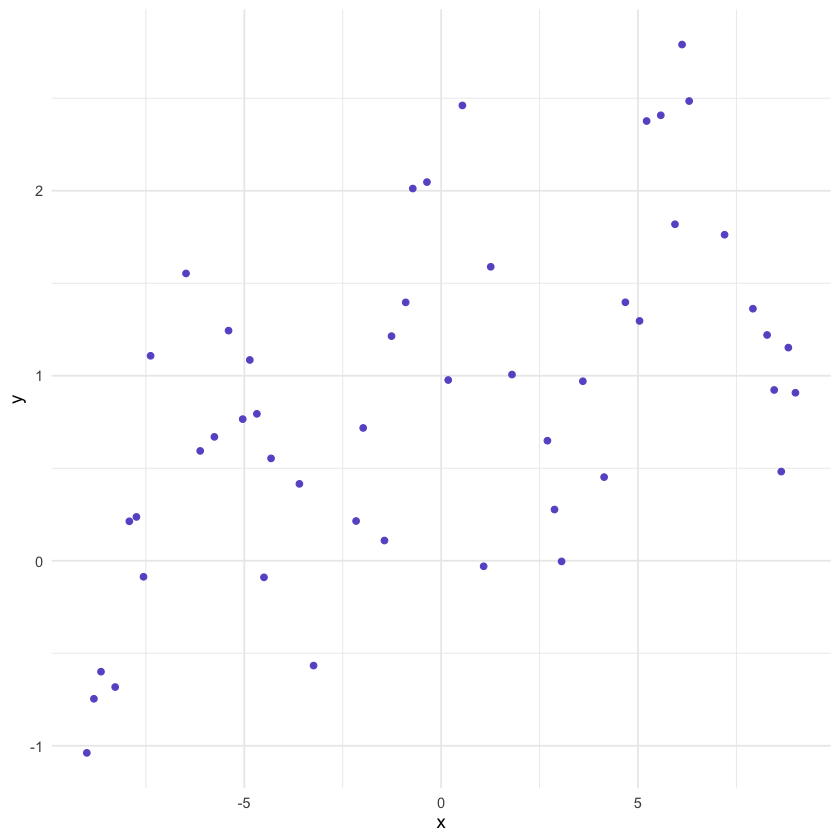

In [6]:
ggplot(train, aes(x, y)) +
geom_point(color = "slateblue") +
theme_minimal()

How would you describe the relationship between $x$ and $y$ based on this plot?

> Based on this plot, the data suggests a weak, positive relationship between $x$ and $y$, with a decent amount of noise.

---
## 2. Bias-variance tradeoff: polynomial regression (4 points)

Recall that in polynomial regression we increase model complexity by expanding $x$ out to the power $k$ (which we call degree).

$$
Y = \hat{\beta}_0 + \sum_{j=1}^K \hat{\beta}_j X^j
\;=\; \operatorname{poly}(X, K)
$$

(a) Fit a 2nd degree polynomial regression model to the training data. Plot the results.


*Hint: Use the* `help` *function to see how to use the* `stat_smooth()` *and* `poly()` *functions.*

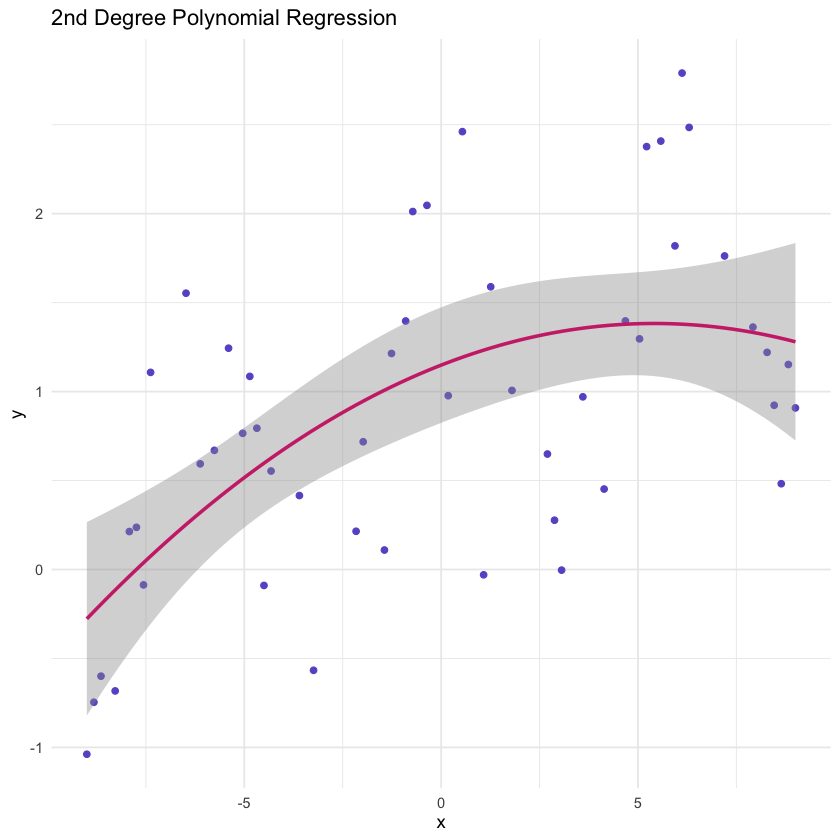

In [7]:
ggplot(train, aes(x, y)) +
geom_point(color = "slateblue") +
stat_smooth(method = "lm", formula = y ~ poly(x, 2), color = "violetred3") +
theme_minimal() +
labs(title = "2nd Degree Polynomial Regression")

How well does this 2nd degree polynomial model qualitatively fit the data? Could it do better?

> The 2nd degree polynomial model captures the general upward trend in the data and adds a slight curve compared to the simple linear model above, which is an improvement. However, given the high variability in the data, the fit, in my opinion, is still fairly weak. It could do better in the sense that higher-degree polynomials might trace the data more closely, but there is a risk of overfitting.

(b) Fit a 12th degree polynomial to the data. Does this do qualitatively better or worse than the 2nd degree model?

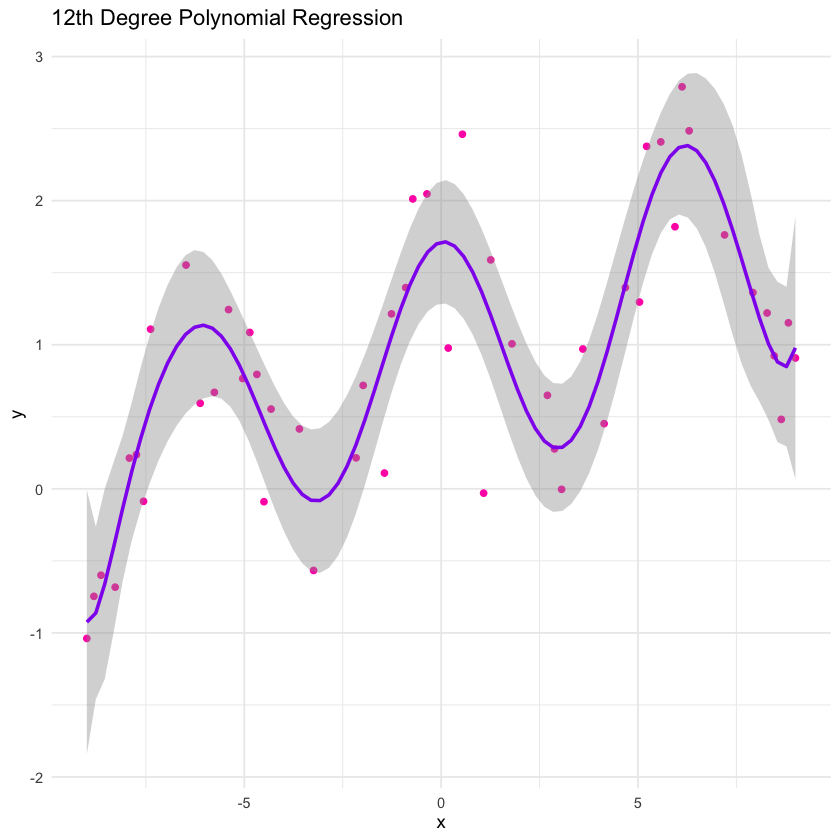

In [8]:
ggplot(train, aes(x, y)) +
geom_point(color = "maroon1") +
stat_smooth(method = "lm", formula = y ~ poly(x, 12), color = "purple2") +
theme_minimal() +
labs(title = "12th Degree Polynomial Regression")

> I think this plot does qualitatively worse as a generalizable model, even though it's visually hugging the training points more closely.

(c) Modify the loop below to estimate the bias-variance tradeoff as model complexity (i.e., degree of the polynomial model, $k$) increases from 2 to 50. Use the training data to fit the model and test data to evaluate its predictive accuracy.

Visualize your results by plotting the *median* squared error for the training data and test data as a function of polynomial degree.


(**Note**: We are using median accuracies here because there are often 1 or 2 outlier values in the higher degree polynomial models that can throw off the accuracy estimates).

Warning message in predict.lm(train_model, newdata = train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(train_model, newdata = test):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(train_model, newdata = train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(train_model, newdata = test):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(train_model, newdata = train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(train_model, newdata = test):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(train_model, newdata = train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(

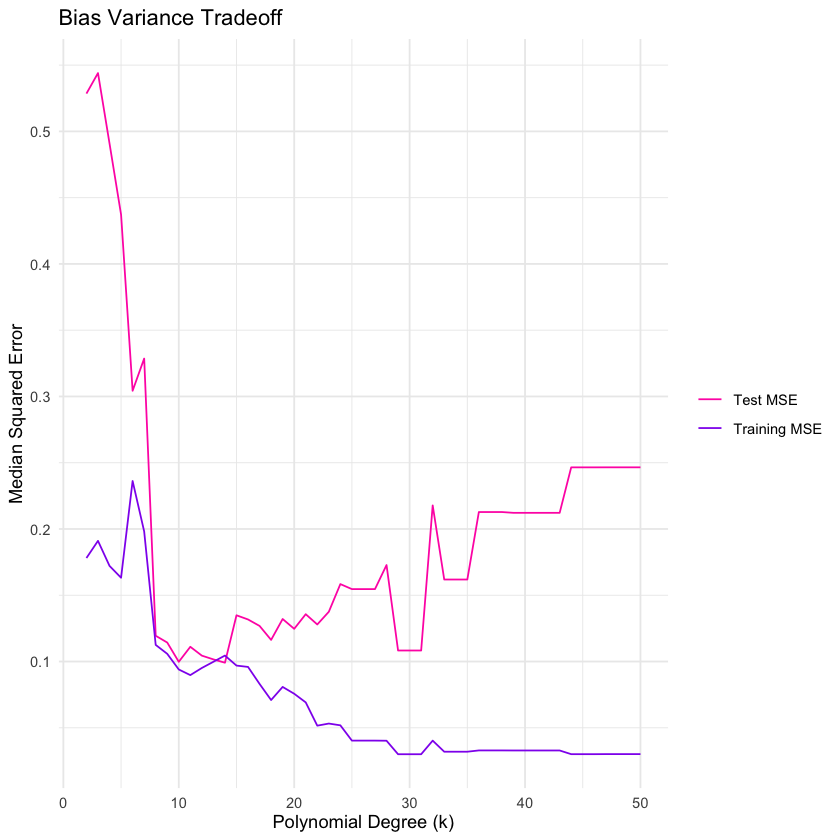

In [20]:
# Now do the variance-bias trade off analysis using regular regression
degree = seq(2,50)

# Need to setup your output vectors
train_rss = matrix(data=NA,nrow=length(degree),ncol=1)
test_rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {
    train_model <- lm(y ~ poly(x, degree=k, raw=TRUE), data=train)
    
    train_pred <- predict(train_model, newdata=train)
    train_rss[k - 1] <- median((train$y - train_pred)^2)
    
    test_pred <- predict(train_model, newdata=test)
    test_rss[k - 1] <- median((test$y - test_pred)^2)
}


# Plot your results here
plot_df <- data.frame(
    degree = rep(degree, 2),
    mse = c(train_rss, test_rss),
    data_type = rep(c("Training MSE", "Test MSE"), each = length(degree))
)

ggplot(plot_df, aes(x = degree, y = mse, color = data_type)) +
geom_line() +
scale_color_manual(values = c("Training MSE" = "purple2", "Test MSE" = "maroon1")) +
labs(
    title  = "Bias Variance Tradeoff",
    x      = "Polynomial Degree (k)",
    y      = "Median Squared Error",
    color  = NULL
) +
theme_minimal()

What do you see as $k$ increase?

> Looking above at the bias-variance tradeoff, it appears that, at low k (high bias) both errors are high because the model is too simple to capture the true relationship. So, I believe this is underfitting. Then, when k is around 8–10, test MSE is minimized, meaning the model is generalizing best. And finally, at high k (high variance), training MSE keeps declining but test MSE rises and becomes unstable/inconsistent, meaning the model is fitting noise in the training data and failing to generalize aka overfitting.
>
> All in all, I think that the polynomial degree is optimal around 8-10, where test error is lowest before variance starts to dominate.

(d) Now copy the code above and let's see what happens when we go beyond $p=n$ (remember, in this case $k=p$). Test polynomial models up to $k=150$. Visualize your results by plotting the *median* squared error for the training data and test data as a function of polynomial degree.

Use the `geom_vline()` function in `ggplot` to draw a vertical line where $k=n$ (here $n$ is the number of observations in the training set). This will make it clear where we cross the threshold for finding *unique* solutions in our data.



Warning message in predict.lm(train_model, newdata = train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(train_model, newdata = test):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(train_model, newdata = train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(train_model, newdata = test):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(train_model, newdata = train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(train_model, newdata = test):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(train_model, newdata = train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(

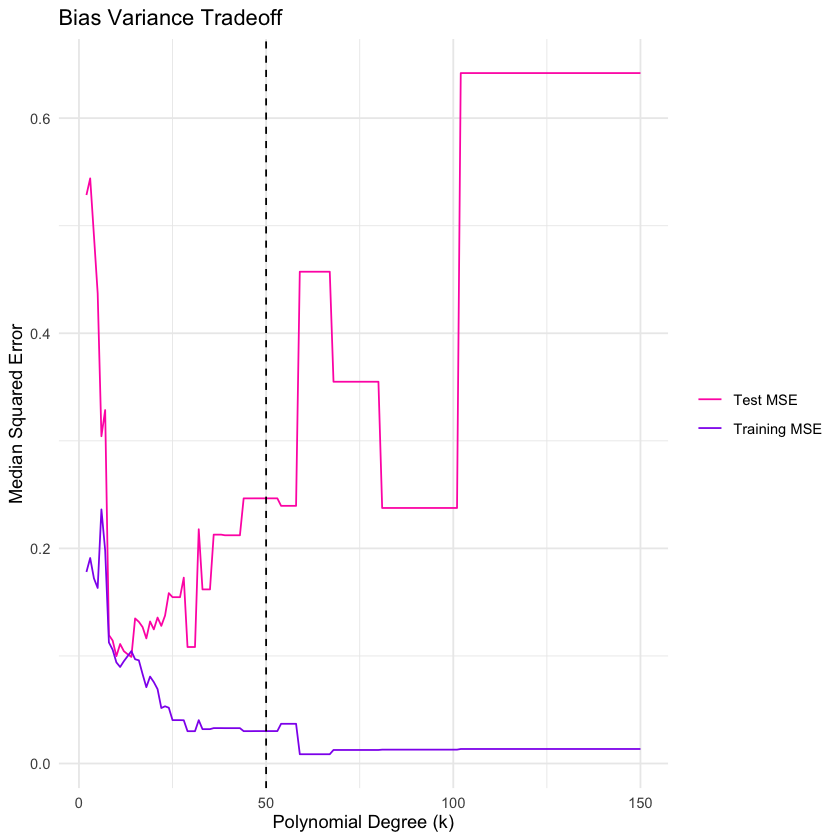

In [21]:
# Now do the variance-bias trade off analysis using regular regression
degree = seq(2,150) # i changed this k to 150

# Need to setup your output vectors
train_rss = matrix(data=NA,nrow=length(degree),ncol=1)
test_rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {
    train_model <- lm(y ~ poly(x, degree=k, raw=TRUE), data=train)
    
    train_pred <- predict(train_model, newdata=train)
    train_rss[k - 1] <- median((train$y - train_pred)^2)
    
    test_pred <- predict(train_model, newdata=test)
    test_rss[k - 1] <- median((test$y - test_pred)^2)
}


# Plot your results here
plot_df <- data.frame(
    degree = rep(degree, 2),
    mse = c(train_rss, test_rss),
    data_type = rep(c("Training MSE", "Test MSE"), each = length(degree))
)

ggplot(plot_df, aes(x = degree, y = mse, color = data_type)) +
geom_line() +
geom_vline(xintercept = nrow(train), linetype = "dashed", color = "black") +
scale_color_manual(values = c("Training MSE" = "purple2", "Test MSE" = "maroon1")) +
labs(
    title  = "Bias Variance Tradeoff",
    x      = "Polynomial Degree (k)",
    y      = "Median Squared Error",
    color  = NULL
) +
theme_minimal()

What do you see as $k$ gets larger than $n$?

> As $k$ gets larger than $n$, there are more parameters than data points. As such, the training MSE drops to basically 0 while the test MSE explodes, indicating extreme overfitting. The dashed vertical line marks where this transition happens.

---
## 3. Applying regularization to the model fits (2 points)

Repeat the previous bias-variance tradeoff test, going up to $k=150$, but now use ridge regression with a sparsity parameter of $\lambda=0.00005$. Plot your results the same way as last time.

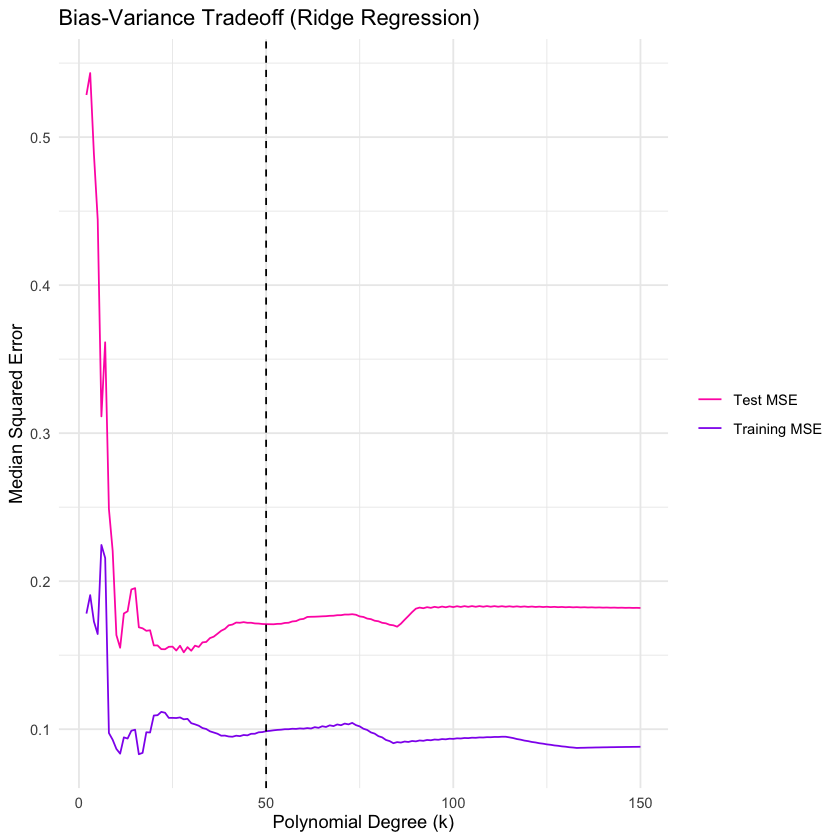

In [19]:
# Now do the variance-bias trade off analysis using ridge regression
lambda=0.00005
degree = seq(2,150)

rm(train_rss, test_rss)
train_rss = matrix(data=NA,nrow=length(degree),ncol=1)
test_rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {
    X_train <- poly(train$x, degree=k, raw=TRUE)
    X_test  <- poly(test$x,  degree=k, raw=TRUE)
    
    # ridge regression
    ridge_model <- glmnet(X_train, train$y, alpha=0, lambda=lambda)
    
    train_pred <- predict(ridge_model, newx=X_train, s=lambda)
    train_rss[k - 1] <- median((train$y - train_pred)^2)
    
    test_pred <- predict(ridge_model, newx=X_test, s=lambda)
    test_rss[k - 1] <- median((test$y - test_pred)^2)
}

# Plot your results here
plot_df <- data.frame(
    degree = rep(degree, 2),
    mse = c(train_rss, test_rss),
    data_type = rep(c("Training MSE", "Test MSE"), each=length(degree))
)

ggplot(plot_df, aes(x=degree, y=mse, color=data_type)) +
geom_line() +
geom_vline(xintercept=nrow(train), linetype="dashed", color="black") +
scale_color_manual(values=c("Training MSE"="purple2", "Test MSE"="maroon1")) +
labs(
    title = "Bias-Variance Tradeoff (Ridge Regression)",
    x     = "Polynomial Degree (k)",
    y     = "Median Squared Error",
    color = NULL
) +
theme_minimal()

What happens now when $k$ gets larger than $n$?

> When $k$ gets larger than $n$, the model stays pretty stable. This is because ridge regression penalizes larger coefficients. In this plot, we can see that both curves remain much smoother on the righthand side of the vertical line compared to the previous plot. This is telling me that the regularization is doing what it's supposed to do. 

---
## 4. Reflection (2 points)

The simulations above should have shown that, when applying a regularization (i.e., a sparsity constraint), the behavior of the bias-variance tradeoff changes. Explain why this happens.

> In the first polynomial regression, increasing k continuously reduces training error because the model is free to grow its coefficients as large as needed to fit every data point. Regularization, like ridge, on the other hand, adds a penalty term to the loss function that discourages large coefficients, effectively constraining how much the model can contort itself to fit the training data. While this reduces variance at the cost of introducing a small amount of bias, I think that the net effect is a model that generalizes much better. As a result, the test MSE curve stays far more stable at higher k values rather than exploding upward and overfitting. 

---
## Bonus (1 extra credit point)
Recall that the $p=n$ threshold defines the limit for finding a *unique* solution to $Y=F(X)$ (i.e., there is only one combination of regression coefficients that is *best* at explaining variance in $Y$). With this in mind, what is regularization doing that works around this upper limit?

> When k > n, there are an infinite amount of combinations of coefficients that perfectly fit the training data, so there is no unique solution. Regularization works around this by adding an additional constraint. Among all the infinite solutions that fit the data, it selects the one with the smallest overall magnitude of coefficients. This extra constraint effectively makes the problem well-determined again even when k > n, which is why ridge regression can still produce stable predictions past the p = n threshold where OLS breaks down entirely.

**DUE:** 11:59pm EST, April 7, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> I did not collaborate with any of my classmates on this assignment. 